# 英国电力需求时序预测 —— 基于 Transformer（无特征工程）

本项目使用英国国家电网的历史电力需求数据，**仅用历史 TSD 值**，通过 Transformer 模型进行时序预测。

与完整版 notebook 的区别：**不做任何特征工程**，模型输入仅为过去 48 个时间步的 TSD 值（1 维），用于对比特征工程对预测精度的影响。

主要步骤：
* **[EDA](#eda)** — 数据清洗与可视化
* **[Transformer 模型](#transformer)** — 使用 PyTorch 实现 Transformer 进行电力需求预测
* **[结果分析](#results)** — 模型评估与可视化

# 目录
* [EDA](#eda)
* [Transformer 模型](#transformer)
* [结果分析](#results)

In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 检测设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda


## 超参数配置

所有可调参数集中在此处，方便统一修改和实验对比。

In [2]:
# ============================================================
# 超参数配置 —— 所有可调参数集中在此
# ============================================================

# --- 随机种子 ---
SEED = 221

# --- 数据划分 ---
THRESHOLD_DATE_1 = "01-01-2023"  # 训练集/验证集分界
THRESHOLD_DATE_2 = "01-01-2024"  # 验证集/测试集分界

# --- 序列窗口 ---
SEQ_LEN = 48  # 滑动窗口长度（48 = 一天的半小时采样数）

# --- DataLoader ---
BATCH_SIZE = 144

# --- Transformer 模型结构 ---
D_MODEL = 64           # 模型内部维度
NHEAD = 4              # 注意力头数
NUM_LAYERS = 2         # Transformer Encoder 层数
DIM_FEEDFORWARD = 128  # 前馈网络隐藏层维度
DROPOUT = 0.5          # Dropout 比率

# --- 训练 ---
NUM_EPOCHS = 50
LEARNING_RATE = 5e-4
PATIENCE = 12         # 早停耐心值
LR_FACTOR = 0.5        # 学习率衰减倍率
LR_PATIENCE = 5        # 学习率衰减耐心值

print("超参数配置完成")

超参数配置完成


## 图表默认参数

In [3]:
# 设置默认字体和字号
small_size = 12
medium_size = 14
large_size = 16

matplotlib.rc("font", size=small_size)
matplotlib.rc("axes", titlesize=small_size)
matplotlib.rc("axes", labelsize=medium_size)
matplotlib.rc("xtick", labelsize=small_size)
matplotlib.rc("ytick", labelsize=small_size)
matplotlib.rc("legend", fontsize=small_size)
matplotlib.rc("axes", titlesize=large_size)

# 加载数据

使用英国国家电网 2019-2024 年的历史电力需求数据。


In [4]:
df = pd.read_csv("data/historic_demand_2009_2024_noNaN.csv")

# 列名转小写
df.columns = df.columns.str.lower()

df.sample(n=7)

,settlement_date,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
90933,2014-03-25 15:30:00,32,15:30:00,42311,43592,38580,593,2524,644,4527,0,5,998,0,999,-251,-425,0,0
8074,2009-06-18 06:00:00,13,6:00:00,26405,28530,24049,648,1717,0,0,0,190,-1390,0,0,-45,0,0,0
204023,2020-09-05 23:30:00,48,23:30:00,21351,21858,19290,896,6527,0,13080,0,8,1177,0,690,171,219,687,0
227603,2022-01-10 06:30:00,14,6:30:00,32697,36353,30131,1378,6527,0,13675,0,189,-813,-490,-806,360,259,-758,0
137713,2016-11-24 08:30:00,18,8:30:00,41265,41987,36873,1236,5077,393,11503,0,11,-111,0,995,243,0,0,0
112205,2015-06-11 21:30:00,44,21:30:00,32075,32781,29268,704,3889,0,8661,0,14,1996,0,984,198,-192,0,0
3496,2009-03-14 20:00:00,41,20:00:00,39496,40386,35573,1050,1419,0,0,0,8,1491,0,0,-282,0,0,0


In [5]:
df.describe()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
count,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000,278512.000000
mean,24.497357,31187.041370,32685.811143,28389.589217,1272.085027,4453.970263,880.245314,8705.061549,6.668416,304.497031,926.247609,53.998768,504.137998,-125.145276,-51.106742,176.336876,0.022405
std,13.852025,7831.306542,7598.781279,7091.113104,966.548452,1955.825654,1710.954426,5869.536138,39.197650,528.163447,1068.846762,354.179475,541.678428,230.383910,263.267266,422.130995,0.147996
min,1.000000,13367.000000,16513.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,-2056.000000,-1030.000000,-1215.000000,-505.000000,-585.000000,-1023.000000,0.000000
25%,12.000000,24907.750000,26608.000000,22676.750000,552.000000,2109.000000,0.000000,2046.000000,0.000000,8.000000,271.000000,0.000000,0.000000,-303.000000,-209.000000,0.000000,0.000000
50%,24.000000,30491.000000,31800.000000,27753.000000,1018.000000,4831.000000,0.000000,11503.000000,0.000000,11.000000,1183.000000,0.000000,726.000000,-148.000000,0.000000,0.000000,0.000000
75%,36.000000,36914.000000,38112.000000,33616.000000,1729.000000,6527.000000,889.000000,13080.000000,0.000000,366.000000,1892.000000,0.000000,994.000000,25.000000,0.000000,338.000000,0.000000
max,48.000000,59095.000000,60147.000000,53325.000000,5930.000000,6622.000000,11224.000000,17197.000000,893.000000,2019.000000,2066.000000,1016.000000,1143.000000,499.000000,504.000000,1033.000000,1.000000


In [6]:
df.shape

(278512, 19)

<a id='eda'></a>
# EDA

## 数据理解

目标变量为 **TSD**（输电系统需求，单位 MW）。数据为半小时采样（每天48个点）。

In [7]:
# 按日期排序
df.sort_values(by=["settlement_date", "settlement_period"], inplace=True, ignore_index=True)

## 数据准备

- 删除含 NaN 的列（nsl_flow, eleclink_flow）
- 删除 settlement_period > 48 的异常行
- 删除 tsd 为 0 的异常天

In [8]:
# 删除含大量缺失值的列（如果存在）
for col in ["nsl_flow", "eleclink_flow"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# 删除异常的 settlement_period
df.drop(index=df[df["settlement_period"] > 48].index, inplace=True)
df.reset_index(drop=True, inplace=True)

# 删除 tsd 为 0 的整天数据
null_days = df.loc[df["tsd"] == 0.0, "settlement_date"].unique().tolist()
null_days_index = []
for day in null_days:
    null_days_index.append(df[df["settlement_date"] == day].index.tolist())
null_days_index = [item for sublist in null_days_index for item in sublist]
if null_days_index:
    df.drop(index=null_days_index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"清洗后数据形状: {df.shape}")

清洗后数据形状: (278512, 19)


## 设置日期时间索引

In [9]:
# 将 settlement_date 设为日期时间索引
df["settlement_date"] = pd.to_datetime(df["settlement_date"])
df.set_index("settlement_date", inplace=True)
df.sort_index(inplace=True)

# 只保留 2019-2024 年的数据
df = df["2019-01-01":"2024-12-31"]

df.head()

,settlement_period,period_hour,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,is_holiday
settlement_date,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,1,0:00:00,23808,25291,22393,2548,5918,0,13052,0,178,1553,0,176,-455,-250,0,1
2019-01-01 00:30:00,2,0:30:00,24402,25720,22962,2475,5918,0,13052,0,27,1554,0,194,-455,-236,0,1
2019-01-01 01:00:00,3,1:00:00,24147,25495,22689,2396,5918,0,13052,0,27,1505,0,581,-410,-311,0,1
2019-01-01 01:30:00,4,1:30:00,23197,24590,21849,2317,5918,0,13052,0,28,1503,0,600,-450,-315,0,1
2019-01-01 02:00:00,5,2:00:00,22316,24346,20979,2236,5918,0,13052,0,525,1503,0,675,-442,-463,0,1


<a id='eda'></a>
## 时序总览

数据形状: (103956, 18)


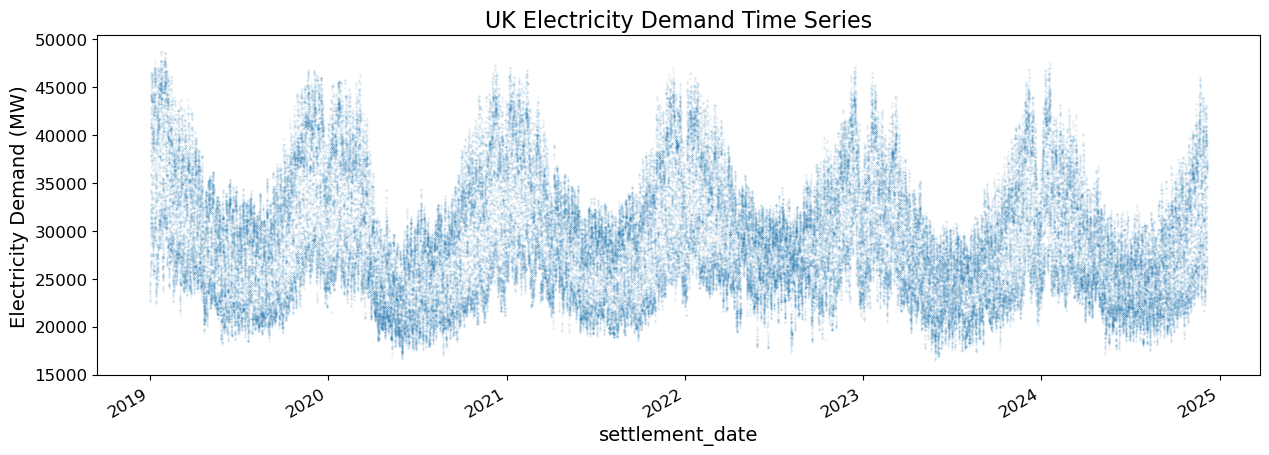

In [10]:
# 无特征工程：仅使用 tsd 列
print(f"数据形状: {df.shape}")
df["tsd"].plot(figsize=(15, 5), style=".", markersize=0.5, alpha=0.3, title="UK Electricity Demand Time Series")
plt.ylabel("Electricity Demand (MW)");

## 数据划分

In [11]:
def mean_absolute_percentage_error(y_true, y_pred):
    """计算平均绝对百分比误差 (MAPE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mape

训练集: 70120, 验证集: 17518, 测试集: 16318


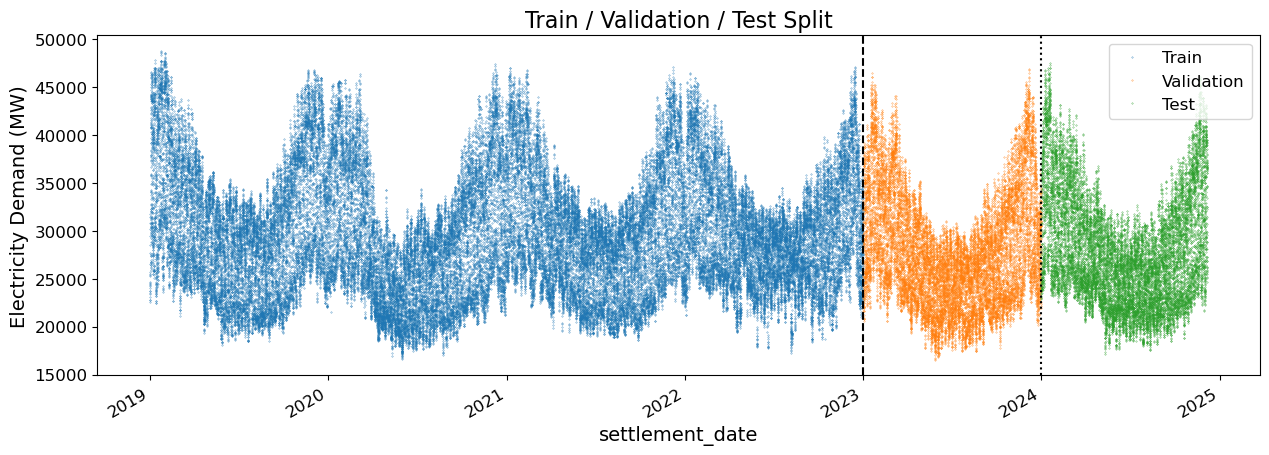

In [12]:
# 设置随机种子
torch.manual_seed(SEED)
np.random.seed(SEED)

train_data = df.loc[df.index < THRESHOLD_DATE_1, "tsd"]
val_data = df.loc[(df.index >= THRESHOLD_DATE_1) & (df.index < THRESHOLD_DATE_2), "tsd"]
test_data = df.loc[df.index >= THRESHOLD_DATE_2, "tsd"]

# 可视化数据划分
fig, ax = plt.subplots(figsize=(15, 5))
train_data.plot(ax=ax, label="Train", style=".", markersize=0.5)
val_data.plot(ax=ax, label="Validation", style=".", markersize=0.5)
test_data.plot(ax=ax, label="Test", style=".", markersize=0.5)
ax.axvline(THRESHOLD_DATE_1, color="k", ls="--")
ax.axvline(THRESHOLD_DATE_2, color="k", ls=":")
ax.set_title("Train / Validation / Test Split")
ax.set_ylabel("Electricity Demand (MW)")
plt.legend();

print(f"训练集: {len(train_data)}, 验证集: {len(val_data)}, 测试集: {len(test_data)}")

<a id='transformer'></a>
# Transformer 时序预测模型（无特征工程）

仅使用历史 TSD 值，不做任何特征工程。模型输入为过去 48 个时间步的 TSD 值（1 维），预测下一个时间步的 TSD。

## 数据预处理

对 TSD 进行 MinMax 归一化，并构建滑动窗口序列。

In [13]:
# MinMax 归一化（仅 tsd）
train_np = train_data.values.astype(np.float32)
val_np = val_data.values.astype(np.float32)
test_np = test_data.values.astype(np.float32)

# 在训练集上计算 min 和 max
tsd_min = train_np.min()
tsd_max = train_np.max()
tsd_range_val = tsd_max - tsd_min

# 归一化到 [0, 1]
train_scaled = (train_np - tsd_min) / tsd_range_val
val_scaled = (val_np - tsd_min) / tsd_range_val
test_scaled = (test_np - tsd_min) / tsd_range_val

print(f"训练集: {train_scaled.shape}, 验证集: {val_scaled.shape}, 测试集: {test_scaled.shape}")
print(f"tsd_min={tsd_min:.0f}, tsd_max={tsd_max:.0f}")

训练集: (70120,), 验证集: (17518,), 测试集: (16318,)
tsd_min=16629, tsd_max=48800


## 构建序列窗口

Transformer 需要序列输入。我们使用滑动窗口将数据组织为 `(batch, seq_len, features)` 的格式。

In [14]:
def create_sequences(data, seq_len):
    """将 1D 时序数据按滑动窗口切分为序列"""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])    # 过去 48 个 tsd 值
        y.append(data[i+seq_len])      # 下一个 tsd 值
    X = np.array(X)
    y = np.array(y)
    # 增加特征维度: (samples, seq_len) → (samples, seq_len, 1)
    X = X[:, :, np.newaxis]
    return X, y

X_train_seq, y_train_seq = create_sequences(train_scaled, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(val_scaled, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(test_scaled, SEQ_LEN)

print(f"训练序列: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"验证序列: X={X_val_seq.shape}, y={y_val_seq.shape}")
print(f"测试序列: X={X_test_seq.shape}, y={y_test_seq.shape}")

训练序列: X=(70072, 48, 1), y=(70072,)
验证序列: X=(17470, 48, 1), y=(17470,)
测试序列: X=(16270, 48, 1), y=(16270,)


In [15]:
# 转换为 PyTorch 张量并创建 DataLoader
train_dataset = TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.float32),
    torch.tensor(y_train_seq, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_seq, dtype=torch.float32),
    torch.tensor(y_val_seq, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_seq, dtype=torch.float32),
    torch.tensor(y_test_seq, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"训练批次数: {len(train_loader)}, 验证批次数: {len(val_loader)}, 测试批次数: {len(test_loader)}")

训练批次数: 487, 验证批次数: 122, 测试批次数: 113


## Transformer 模型定义

数据流向：`输入(1维 tsd) → 线性投影(d_model维) → 位置编码 → Transformer Encoder × N层 → 取最后时间步 → 概率输出(μ, σ²)`

In [16]:
class PositionalEncoding(nn.Module):
    """正弦-余弦位置编码"""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TimeSeriesTransformer(nn.Module):
    """
    基于 Transformer Encoder 的时序预测模型（无特征工程版本）

    输入仅为过去 48 个时间步的 TSD 值（1 维特征）
    """
    def __init__(self, n_features, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.mu_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self.logvar_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        mu = self.mu_head(x).squeeze(-1)
        log_var = self.logvar_head(x).squeeze(-1)
        var = torch.exp(log_var)
        return mu, var


# 实例化模型：n_features=1（仅 tsd）
N_FEATURES = 1
model = TimeSeriesTransformer(
    n_features=N_FEATURES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
).to(device)

print(model)
print(f"\n可训练参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TimeSeriesTransformer(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.5, inplace=False)
        (dropout2): Dropout(p=0.5, inplace=False)
      )
    )
  )
  (mu_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=32, out_fe

## 模型训练

使用 GaussianNLL 损失函数和 Adam 优化器，并实现早停机制。

In [17]:
# 高斯负对数似然损失（概率分布输出）
criterion = nn.GaussianNLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE
)

# 训练记录
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):

    # ---- 训练阶段 ----
    model.train()
    total_train_loss = 0.0
    num_train_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        mu, var = model(X_batch)
        loss = criterion(mu, y_batch, var)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        num_train_batches += 1

    avg_train_loss = total_train_loss / num_train_batches

    # ---- 验证阶段 ----
    model.eval()
    total_val_loss = 0.0
    num_val_batches = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            mu, var = model(X_batch)
            loss = criterion(mu, y_batch, var)

            total_val_loss += loss.item()
            num_val_batches += 1

    avg_val_loss = total_val_loss / num_val_batches

    # ---- 记录损失 ----
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # ---- 学习率调度 ----
    scheduler.step(avg_val_loss)

    # ---- 早停检查 ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    # ---- 打印日志 ----
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train NLL: {avg_train_loss:.6f} | "
              f"Val NLL: {avg_val_loss:.6f} | "
              f"Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at Epoch {epoch+1}")
        break

# 恢复最优模型权重
model.load_state_dict(best_model_state)
model.to(device)
print("Best model weights loaded")

Epoch   1/50 | Train NLL: -1.273095 | Val NLL: -2.188396 | Patience: 0/12
Epoch   2/50 | Train NLL: -1.883639 | Val NLL: -2.349537 | Patience: 0/12
Epoch   3/50 | Train NLL: -2.047649 | Val NLL: -2.613016 | Patience: 0/12
Epoch   4/50 | Train NLL: -2.169312 | Val NLL: -2.762266 | Patience: 0/12
Epoch   5/50 | Train NLL: -2.227204 | Val NLL: -2.682130 | Patience: 1/12
Epoch   6/50 | Train NLL: -2.271138 | Val NLL: -2.771927 | Patience: 0/12
Epoch   7/50 | Train NLL: -2.330686 | Val NLL: -2.850123 | Patience: 0/12
Epoch   8/50 | Train NLL: -2.356638 | Val NLL: -2.864462 | Patience: 0/12
Epoch  10/50 | Train NLL: -2.436861 | Val NLL: -2.906319 | Patience: 0/12
Epoch  11/50 | Train NLL: -2.444882 | Val NLL: -2.918079 | Patience: 0/12
Epoch  12/50 | Train NLL: -2.476343 | Val NLL: -3.028550 | Patience: 0/12
Epoch  15/50 | Train NLL: -2.532791 | Val NLL: -3.025337 | Patience: 3/12
Epoch  18/50 | Train NLL: -2.584083 | Val NLL: -3.093425 | Patience: 0/12
Epoch  20/50 | Train NLL: -2.606097 | 

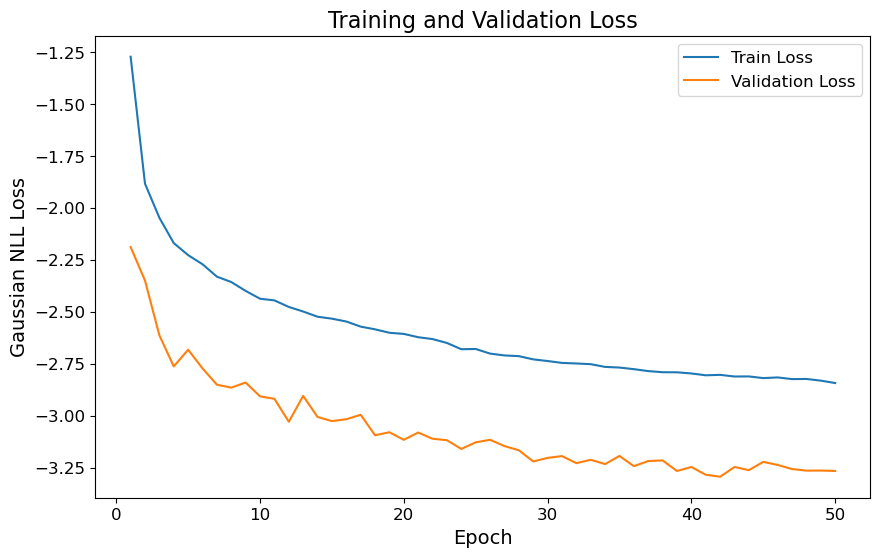

In [18]:
# 绘制训练和验证损失曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gaussian NLL Loss")
ax.set_title("Training and Validation Loss")
ax.legend(loc="best");

## 预测与反归一化

模型训练在归一化数据上进行，因此需要将预测结果反归一化回原始尺度。

In [19]:
# 在测试集上预测
model.eval()
mu_list = []
std_list = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        mu, var = model(X_batch)
        mu_list.append(mu.cpu().numpy())
        std_list.append(torch.sqrt(var).cpu().numpy())

# 拼接所有 batch 的预测结果
pred_scaled = np.concatenate(mu_list)
std_scaled = np.concatenate(std_list)

# 反归一化
pred_original = pred_scaled * tsd_range_val + tsd_min
std_original = std_scaled * tsd_range_val

# 构建结果 DataFrame
y_test = test_data.iloc[SEQ_LEN:]
result_frame = y_test.to_frame()
result_frame["pred_transformer"] = pred_original
result_frame["std_transformer"] = std_original

print(f"预测结果: {len(pred_original)} 个样本")

预测结果: 16270 个样本


<a id='results'></a>
# 结果分析

## 测试集预测可视化

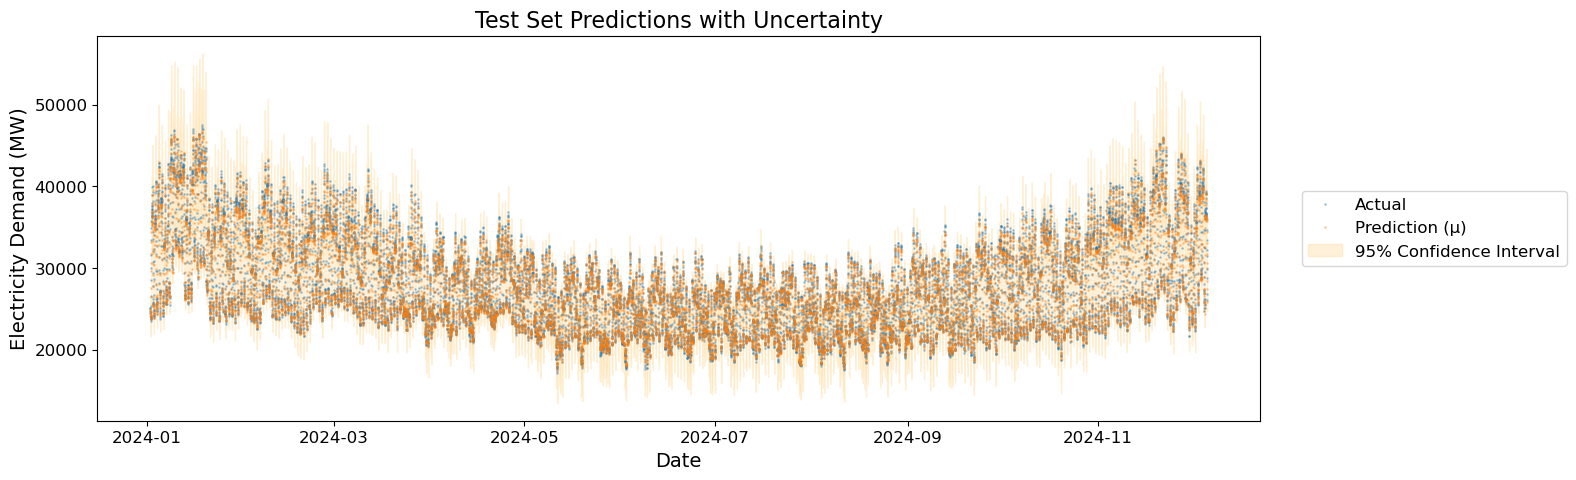

In [20]:
# 测试集全局预测对比（含 95% 置信区间）
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(result_frame.index, result_frame["tsd"], "o", markersize=1, alpha=0.3, label="Actual")
ax.plot(result_frame.index, result_frame["pred_transformer"], "o", markersize=1, alpha=0.3, label="Prediction (μ)")
ax.fill_between(
    result_frame.index,
    result_frame["pred_transformer"] - 1.96 * result_frame["std_transformer"],
    result_frame["pred_transformer"] + 1.96 * result_frame["std_transformer"],
    alpha=0.15, color="orange", label="95% Confidence Interval"
)
ax.legend(loc="center", bbox_to_anchor=(1.15, 0.5))
ax.set_title("Test Set Predictions with Uncertainty")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_xlabel("Date");

### 两周细节对比

选取一段两周的时间窗口，观察模型对日内模式的捕捉能力。

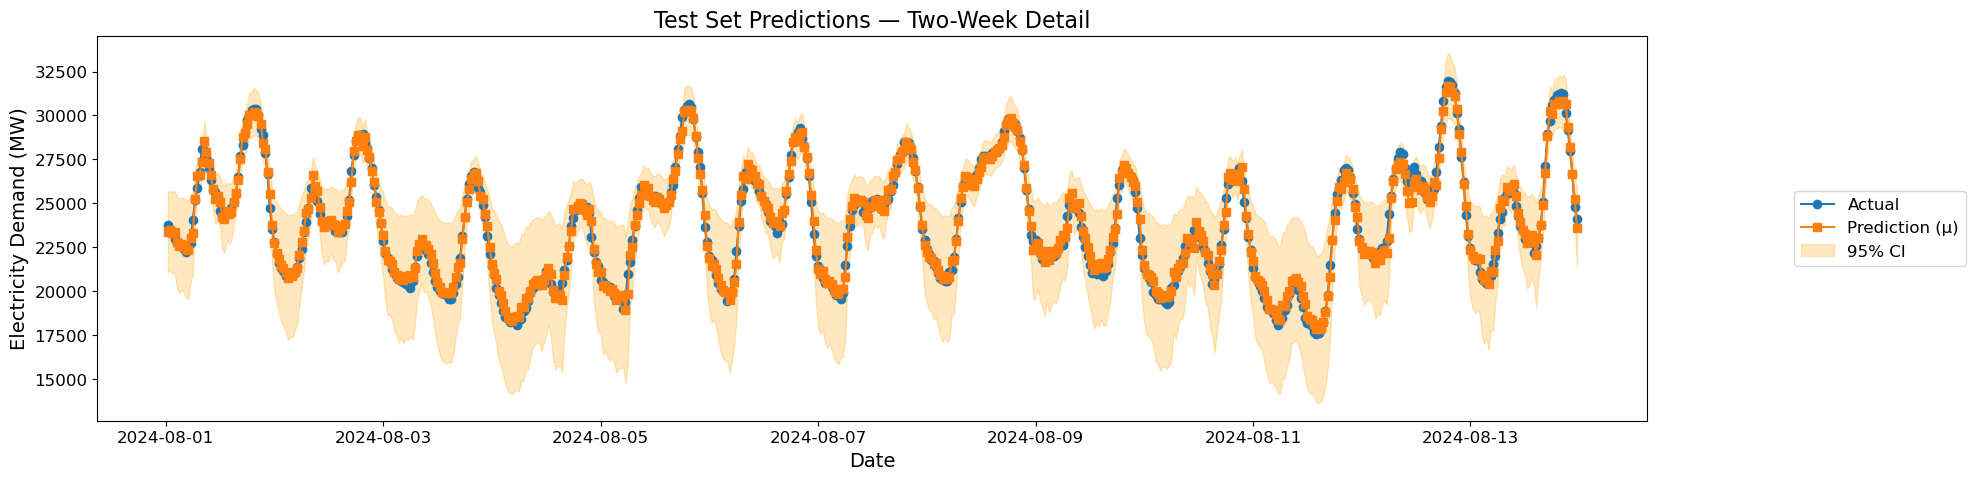

In [21]:
begin = "08-01-2024"
end = "08-14-2024"

mask = (result_frame.index > begin) & (result_frame.index < end)

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(result_frame.loc[mask].index, result_frame.loc[mask]["tsd"], "-o", label="Actual")
ax.plot(result_frame.loc[mask].index, result_frame.loc[mask]["pred_transformer"], "-s", label="Prediction (μ)")
ax.fill_between(
    result_frame.loc[mask].index,
    result_frame.loc[mask]["pred_transformer"] - 1.96 * result_frame.loc[mask]["std_transformer"],
    result_frame.loc[mask]["pred_transformer"] + 1.96 * result_frame.loc[mask]["std_transformer"],
    alpha=0.25, color="orange", label="95% CI"
)
ax.legend(loc="center", bbox_to_anchor=(1.15, 0.5))
ax.set_title("Test Set Predictions — Two-Week Detail")
ax.set_ylabel("Electricity Demand (MW)")
ax.set_xlabel("Date");

通过折线图可以确认 Transformer 预测不是原始数据的简单滞后版本，而是真正捕捉到了日内和周内的用电模式。

## 性能指标

In [22]:
mape_transformer = mean_absolute_percentage_error(
    result_frame["tsd"], result_frame["pred_transformer"]
)

rmse_transformer = np.sqrt(np.mean(
    (result_frame["tsd"].values - result_frame["pred_transformer"].values) ** 2
))

print(f"Transformer 模型 MAPE: {mape_transformer:.2f}%")
print(f"Transformer 模型 RMSE: {rmse_transformer:.2f} MW")

Transformer 模型 MAPE: 1.32%
Transformer 模型 RMSE: 502.78 MW


## 结果总结

In [23]:
summary_df = pd.DataFrame({
    "Transformer": [mape_transformer, rmse_transformer],
}, index=["MAPE (%)", "RMSE (MW)"])

summary_df.style.format('{:.2f}')

,Transformer
MAPE (%),1.32
RMSE (MW),502.78


## 总结

本 notebook 仅使用历史 TSD 值（无特征工程），通过 Transformer 模型预测未来电力需求。

对比完整版 notebook（含特征工程：时间特征 + lag 特征），可以观察特征工程对预测精度的影响。